# 1.3 カーネルリッジ回帰（Kernel Ridge Regression）

**原典**: scikit-learn User Guide [1.3. Kernel ridge regression](https://scikit-learn.org/stable/modules/kernel_ridge.html)（v1.9.1）

| | |
|---|---|
| **このノートで分かるようになること** | ・「カーネルトリック」で、線形モデルが曲線を学習できる理由を説明できる<br>・カーネルリッジ回帰の答えが、式 1 本（閉形式）で求まる仕組みが分かる<br>・RBF カーネルの `gamma` と正則化の `alpha` の役割が分かり、グリッドサーチで選べる<br>・サポートベクター回帰（SVR）との違い（損失関数、スパース性、速さ）を説明できる |
| **前提** | [1.1 線形モデル（1/4）](./01_linear_models_1_ols_regularization.ipynb) の Ridge と、[（4/4）](./01_linear_models_4_robust_poly.ipynb) の多項式特徴 |
| **目安時間** | 60〜90 分 |

### このノートの読み方

| 記号 | 意味 |
|---|---|
| 📖 **ガイドの解説** | 公式ガイドの内容を日本語で説明したもの |
| 💡 **補足** | 初学者向けに、ガイドにない前提知識・直感・たとえ話・数式を足したもの |
| 📚 **用語** / 🔢 **数式を読む** | 初出の用語の説明 / 数式の記号を 1 つずつ説明し、日本語で読み下したもの |
| 🎯 **なぜ使うのか** / 🏭 **利用例** / 🕰️ **歴史** | 手法が使われる理由・実際の応用・生まれた経緯（参考情報） |
| 🧪 **やってみよう** / 👀 **結果の読み方** | コードで確かめる / 出力のどこを見ればよいか |
| ⚠️ **つまずきポイント** | 実際に動かして分かった落とし穴（ガイドに書かれていないものを含む） |
| 🏢 **実務での選ばれ方** | 実際の業務で、その手法が選ばれる場面・選ばれない場面・よく組み合わせる手法 |
| 📐 **もっと詳しく（数式編）** | 本文の式を、数値の例・導き方・図の読み方まで含めて、さらに詳しく説明した別ファイルへのリンク |

> **この節の特徴**: ガイドの 1.3 節は短く、数式が載っていません。このノートでは、ガイドが前提にしている数式（カーネルリッジ回帰の解き方、RBF カーネル、SVR の損失関数）を **💡 補足**として追加し、ガイドの記述（📖）とは区別して書いています。式のさらに詳しい説明（数値の例・導き方）は数式編にあります。

### 🗺️ 3 行でいうと

1. **カーネルリッジ回帰**は、「似ている度合い」（**カーネル**）を使って、Ridge 回帰のまま**曲線**を学習する方法。
2. 予測は「新しい点と、学習データ 1 件ずつとの**似ている度合い × そのデータの発言力**」の合計。発言力は連立方程式を 1 回解くだけで決まる。
3. RBF カーネルの `gamma`（どこまでを似ているとみなすか）と `alpha`（正則化）を、組み合わせで選ぶ。SVR とは同じ形のモデルで、損失（外れ具合の測り方）が違う。

> 📐 **数式について**: 本文の式は、記号の表（🔢）と「日本語で読むと」で読めるようにしています。式を**もっと詳しく**（小さな数値で計算してみる・なぜこの形になるのか）知りたい人は、各所のリンクから [数式編](./math/03_kernel_ridge_math.md) へ。中学で習う範囲から必要な数学の道具は [数学の準備](../00_math_primer.md)、用語は [用語集](../glossary.md) にまとめています。

### 目次

0. 導入: カーネルリッジ回帰とは
1. 💡 数式で理解する: Ridge からカーネルリッジへ
2. 💡 RBF カーネルと 2 つのハイパーパラメータ
3. 📖 SVR との比較: 損失関数とスパース性
4. 📖 ガイドの図 1 の再現: 学習と予測の速さ
5. 📖 ガイドの図 2 の再現: データ量による速さの変化
6. 💡 ガウス過程回帰との関係
7. まとめ・確認クイズ

## セットアップ

実行済みの出力つきで保存しています。手元で動かす場合は、上から順に実行してください。

> ⚠️ このノートには**実行時間を測る**実験があります。時間の値は、実行するコンピュータによって変わります。

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # グラフで日本語を表示するため

from sklearn import linear_model as lm

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.figsize": (6, 3.6), "figure.dpi": 80, "axes.grid": True})
rng = np.random.RandomState(0)  # 乱数の種を固定（同じ結果を再現するため）

import time
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel

def best_time(func, repeat=3):
    # 実行時間の計測: 何回か実行して、いちばん速い値を使う（ほかの処理の影響を減らすため）
    times = []
    for _ in range(repeat):
        t = time.perf_counter(); func(); times.append(time.perf_counter() - t)
    return min(times)

---
## 0. 導入: カーネルリッジ回帰とは

### 📖 ガイドの解説

カーネルリッジ回帰（KRR）は、Ridge 回帰と分類（L2 ノルムで正則化した、線形の最小二乗法）と、**カーネルトリック**を組み合わせたものです。そのため、KRR は、使うカーネルとデータによって決まる**空間の中で、線形の関数**を学習します。カーネルが非線形なら、これは**元の空間では非線形の関数**に当たります。

> 📚 **用語**
> - **カーネル（kernel）**: 2 つのデータ点 $x$, $x'$ を受け取り、「どれだけ似ているか」を 1 つの数で返す関数 $k(x, x')$。数学的には、ある特徴空間での**内積**になっている関数。
> - **内積**: 2 つのベクトルの要素ごとの積の和（$a \cdot b = a_1 b_1 + a_2 b_2 + \dots$）。向きが近いほど大きくなるので、「似ている度合い」の一種。
> - **特徴空間**: 元の特徴を変換して作った、新しい（多くは高次元の）特徴の空間。1.1 の 4/4 で、$[x_1, x_2]$ から $[1, x_1, x_2, x_1^2, x_1 x_2, x_2^2]$ を作ったのがその例。
> - **カーネルトリック**: 特徴空間の座標を**実際には計算せず**、カーネル関数だけで特徴空間の内積を計算するテクニック。特徴空間が非常に高次元（無限次元でも）でも、計算量が増えない。

### 💡 補足: カーネルトリックのたとえ

1.1 の 4/4 では、$x^2$ や $x_1 x_2$ のような特徴を**自分で作って**から線形モデルを学習しました。特徴の数は次数とともに爆発的に増えます（特徴 100 個の 3 次多項式なら約 17 万個）。

カーネルトリックは、「新しい特徴を全部作らなくても、**2 点の似ている度合い（内積）さえ計算できれば**、同じ答えが出せる」という発見です。

たとえるなら、家賃を予測するのに、物件の特徴を何百項目も書き出す代わりに、「**過去の物件のうち、この物件に似ている物件の家賃**を、似ている度合いで重み付けして足す」ようなものです。カーネルリッジ回帰の予測は、実際にこの形になります（1 章で数式で確かめます）。

### 🎯 なぜ使うのか

- **非線形の関係**を、線形モデル（Ridge）と同じくらい簡単な計算で学習できる。
- 答えが**閉形式**（連立方程式を 1 回解くだけ）で求まるので、反復計算の収束を気にしなくてよい。
- カーネルを取り替えるだけで、多項式、なめらかな曲線、周期的なパターンなど、さまざまな形を表せる。

### 🏭 利用例

- **化学・材料科学**: 分子や結晶の構造から、エネルギーや物性値を予測する。数百〜数千件程度のデータで高い精度が出るので、量子化学計算の代わりに使う研究が 2010 年代に広まりました。
- **地球統計学**: 観測点のデータから、観測していない地点の値（地下資源の量、気温など）を推定する**クリギング**は、数学的にカーネルリッジ回帰（とガウス過程回帰）と深く関係しています。
- 中規模（数千件程度）までのデータでの、なめらかな非線形回帰全般。

### 🕰️ 歴史（参考情報）

- **1909 年**: 数学者**マーサー（J. Mercer）**が、ある条件を満たす関数は「何かの空間での内積」として表せることを示しました（マーサーの定理）。これがカーネル法の数学的な土台です。
- **1964 年**: ソ連の研究者**アイゼルマン、ブラヴェルマン、ロゾノエル**が、パターン認識の「ポテンシャル関数法」で、カーネルを内積として使う考え方を示しました。
- **1992 年**: **ボーザー、ギヨン、ヴァプニク**が、サポートベクターマシン（SVM）にカーネルトリックを組み合わせ、カーネル法が機械学習で一躍広まりました。
- **1998 年**: **ソーンダース、ガメルマン、ヴォフク**が、Ridge 回帰を「双対変数」で解くことでカーネルを使えるようにした論文を発表しました。これがカーネルリッジ回帰の代表的な出発点とされます。
- ガイドの参考文献は、ケビン・マーフィーの教科書 *Machine Learning: A Probabilistic Perspective*（2012 年）の 14.4.3 節です。

### 🧪 やってみよう: 直線しか引けない Ridge と、曲線を学習するカーネルリッジ

sin 曲線にノイズを加えたデータに、(1) 普通の Ridge、(2) 多項式カーネルの KRR、(3) RBF カーネルの KRR を当てはめます。

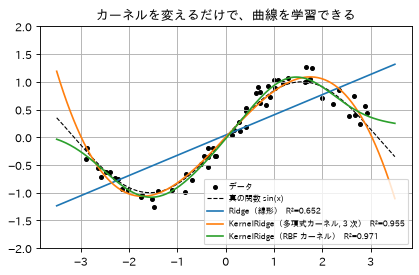

In [2]:
rng = np.random.RandomState(0)
X = np.sort(rng.uniform(-3, 3, 60))[:, None]
y = np.sin(X[:, 0]) + 0.15 * rng.randn(60)
grid = np.linspace(-3.5, 3.5, 300)[:, None]

models = {
    "Ridge（線形）": lm.Ridge(alpha=1.0),
    "KernelRidge（多項式カーネル, 3 次）": KernelRidge(alpha=1.0, kernel="poly", degree=3),
    "KernelRidge（RBF カーネル）": KernelRidge(alpha=0.1, kernel="rbf", gamma=0.5),
}
plt.scatter(X, y, s=12, c="black", label="データ")
plt.plot(grid, np.sin(grid), "k--", lw=1, label="真の関数 sin(x)")
for name, m in models.items():
    plt.plot(grid, m.fit(X, y).predict(grid), label=f"{name}  R²={m.score(X, y):.3f}")
plt.ylim(-2, 2); plt.legend(fontsize=7); plt.title("カーネルを変えるだけで、曲線を学習できる"); plt.show()

### 👀 結果の読み方

- 普通の Ridge は直線しか引けないので、sin 曲線を捉えられません。
- 多項式カーネルと RBF カーネルの KRR は、同じ「Ridge」の仕組みなのに、曲線を学習しています。
- 多項式カーネル（3 次）は、データの外側（x < −3、x > 3）で 3 次式らしく大きく曲がっていきます。RBF カーネルは、データから離れると 0 に戻っていきます。**データのない場所での振る舞いは、カーネルの選び方で決まります**（この点は 1 章の ⚠️ でもう一度扱います）。

> 📚 **用語**: **R²（決定係数）** — 回帰の当てはまりの良さを表す指標。1 なら完全に当たり、0 なら「平均値を答えるだけ」と同じ。`score` メソッドが返す値。

---
## 1. 💡 数式で理解する: Ridge からカーネルリッジへ

（この章はガイドに書かれていない補足です。ガイドの参考文献の Murphy の教科書などに載っている、標準的な導き方を説明します。）

### ステップ 1: 特徴空間での Ridge 回帰

元の特徴 $x$ を関数 $\phi$ で特徴空間に変換し、そこで Ridge 回帰をします。

$$\min_{w} \sum_{i=1}^{n} \left( y_i - w^T \phi(x_i) \right)^2 + \alpha \|w\|_2^2$$

### 🔢 数式を読む

| 記号 | 意味 |
|---|---|
| $\phi(x_i)$ | サンプル $i$ を特徴空間に変換したもの（1.1 の 4/4 の `PolynomialFeatures` の出力に当たる） |
| $w$ | 特徴空間での係数。特徴空間が大きいと、$w$ も巨大（無限次元のことも）になる |
| $w^T \phi(x_i)$ | 特徴空間での線形の予測 |
| $\alpha \lVert w\rVert _2^2$ | Ridge の L2 正則化。`KernelRidge(alpha=...)` |

**日本語で読むと**: 変換した特徴で、普通の Ridge 回帰をする。ただし $w$ が巨大なので、このままでは計算できない。

### ステップ 2: 答えは「学習データの重み付き和」になる

Ridge の答えの係数 $w$ は、必ず学習データの変換後の点 $\phi(x_i)$ の重み付き和の形 $w = \sum_i a_i \phi(x_i)$ で書けることが知られています（**表現定理**）。これを使うと、巨大な $w$ の代わりに、サンプル数 $n$ 個の重み $a_1, \dots, a_n$ を求めればよくなります。この $a$ を**双対係数**と呼び、scikit-learn の `dual_coef_` 属性に当たります。

計算すると、$a$ は次の**連立方程式**の解になります。

$$(K + \alpha I) \, a = y, \qquad K_{ij} = k(x_i, x_j) = \phi(x_i)^T \phi(x_j)$$

新しい点 $x$ の予測は次のとおりです。

$$\hat{y}(x) = w^T \phi(x) = \sum_{i=1}^{n} a_i \, k(x_i, x)$$

### 🔢 数式を読む

| 記号 | 形 | 意味 |
|---|---|---|
| $K$ | $n \times n$ | **カーネル行列（グラム行列）**。全学習サンプルの組について、似ている度合い $k(x_i, x_j)$ を並べた表 |
| $I$ | $n \times n$ | 単位行列 |
| $K + \alpha I$ | $n \times n$ | カーネル行列の対角に $\alpha$ を足したもの。正則化のおかげで必ず解ける |
| $a$ | $n$ | 双対係数（`dual_coef_`）。学習サンプル 1 つ 1 つの「発言力」 |
| $k(x_i, x)$ | — | 学習サンプル $i$ と、新しい点 $x$ の似ている度合い |

**日本語で読むと**: 予測は「新しい点と、各学習サンプルとの似ている度合い」に、各サンプルの発言力 $a_i$ を掛けて足したもの。発言力 $a$ は、$n$ 元の連立方程式を 1 回解くだけで求まる。**特徴空間の座標 $\phi$ は、どこにも出てこない**（カーネル $k$ だけで計算できる）。これがカーネルトリックです。

> 📚 **用語**
> - **双対（dual）**: 同じ最適化問題を、別の変数（ここでは $w$ の代わりに $a$）で表し直したもの。元の形を**主問題**、表し直した形を**双対問題**と呼ぶ。
> - **閉形式（closed-form）**: 反復計算なしに、式で直接求まる解。KRR は連立方程式を 1 回解くだけ。

> 📐 **もっと詳しく**: [数式編「Ridge からカーネルリッジ回帰へ」](./math/03_kernel_ridge_math.md#krr)（数値の例・導き方つき）

### 🧪 やってみよう: 連立方程式を自分で解いて、`KernelRidge` と照合する

（式どおりに計算して確かめる実験です。とばしても先へ進めます）

In [3]:
alpha, gamma = 0.1, 0.5
krr = KernelRidge(alpha=alpha, kernel="rbf", gamma=gamma).fit(X, y)

K = rbf_kernel(X, X, gamma=gamma)                     # カーネル行列 (60 × 60)
a = np.linalg.solve(K + alpha * np.eye(len(X)), y)    # (K + αI) a = y を解く
pred_manual = rbf_kernel(grid, X, gamma=gamma) @ a    # ŷ(x) = Σ a_i k(x_i, x)

print("カーネル行列の形:", K.shape)
print("双対係数 a と dual_coef_ が一致:", np.allclose(a, krr.dual_coef_))
print("手計算の予測と predict が一致:", np.allclose(pred_manual, krr.predict(grid)))

カーネル行列の形: (60, 60)
双対係数 a と dual_coef_ が一致: True
手計算の予測と predict が一致: True


👀 `KernelRidge` の中身は、本当に「カーネル行列を作って、連立方程式を 1 回解く」だけでした。学習データが 60 件なので、60 × 60 の行列を扱っています。

### 🧪 やってみよう: 多項式カーネル ＝ 多項式特徴 + Ridge

1.1 の 4/4 の多項式特徴とのつながりを確かめます。1 次元の $x$ に対する 3 次の多項式カーネル $k(x, x') = (x x' + 1)^3$ を展開すると、

$$(x x' + 1)^3 = 1 + 3 x x' + 3 x^2 x'^2 + x^3 x'^3$$

なので、特徴 $\phi(x) = [1,\ \sqrt{3} x,\ \sqrt{3} x^2,\ x^3]$ の内積と同じです。

> 📐 **もっと詳しく**: [数式編「多項式カーネルと多項式特徴」](./math/03_kernel_ridge_math.md#polykernel)（数値の例・導き方つき）

この特徴を**自分で作って** Ridge（切片なし）を当てはめると、多項式カーネルの KRR と同じ答えになるはずです。

In [4]:
krr_poly = KernelRidge(alpha=1.0, kernel="poly", degree=3, gamma=1, coef0=1).fit(X, y)

def phi(x):                                           # (x x' + 1)^3 に対応する特徴
    x = x[:, 0]
    return np.c_[np.ones_like(x), np.sqrt(3) * x, np.sqrt(3) * x ** 2, x ** 3]

ridge_poly = lm.Ridge(alpha=1.0, fit_intercept=False).fit(phi(X), y)
print("カーネル行列 = φ(X) φ(X)^T:", np.allclose(polynomial_kernel(X, X, degree=3, gamma=1, coef0=1), phi(X) @ phi(X).T))
print("KRR（多項式カーネル）と Ridge（手作りの特徴）の予測が一致:",
      np.allclose(krr_poly.predict(grid), ridge_poly.predict(phi(grid))))

カーネル行列 = φ(X) φ(X)^T: True
KRR（多項式カーネル）と Ridge（手作りの特徴）の予測が一致: True


👀 一致しました。多項式カーネルは、多項式特徴を**作らずに**同じ計算をしているのです。特徴 1 個・3 次なら特徴は 4 個で済みますが、特徴が 100 個になると多項式特徴は約 17 万個になります。カーネルなら、どれだけ特徴が増えても $n \times n$ のカーネル行列を作るだけです。

> 🔢 **scikit-learn の多項式カーネル**: `kernel="poly"` は $k(x, x') = (\gamma \, x^T x' + c_0)^d$ です。`gamma` が $\gamma$、`coef0` が $c_0$、`degree` が $d$ に当たります。

### 🧪 やってみよう: 線形カーネル ＝ 切片なしの Ridge

In [5]:
krr_lin = KernelRidge(alpha=1.0, kernel="linear").fit(X, y)
print("KernelRidge(kernel='linear') と Ridge(fit_intercept=False) が一致:",
      np.allclose(krr_lin.predict(grid), lm.Ridge(alpha=1.0, fit_intercept=False).fit(X, y).predict(grid)))
print("Ridge(fit_intercept=True) とは一致しない:",
      not np.allclose(krr_lin.predict(grid), lm.Ridge(alpha=1.0).fit(X, y).predict(grid)))

KernelRidge(kernel='linear') と Ridge(fit_intercept=False) が一致: True
Ridge(fit_intercept=True) とは一致しない: True


### ⚠️ つまずきポイント（ガイドに書かれていない）: KernelRidge には切片がない

上の結果のとおり、`KernelRidge` は**切片（`intercept_`）を学習しません**（`fit_intercept` という引数もありません）。目的変数の平均が 0 から遠いと、困ったことが起きます。目的変数に +10 を足したデータで確かめます。

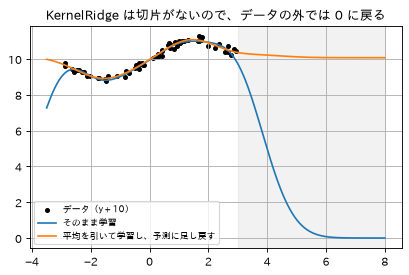

x = 6, 10 の予測（そのまま）: [0.078 0.   ]
x = 6, 10 の予測（平均を引いた場合）: [10.08  10.076]


In [6]:
y_shift = y + 10                                          # 平均がおよそ 10 のデータ
far = np.array([[6.0], [10.0]])                           # データの範囲（−3〜3）から遠い点

raw = KernelRidge(alpha=0.1, kernel="rbf", gamma=0.5).fit(X, y_shift)
y_mean = y_shift.mean()
centered = KernelRidge(alpha=0.1, kernel="rbf", gamma=0.5).fit(X, y_shift - y_mean)   # 平均を引いてから学習

g2 = np.linspace(-3.5, 8, 300)[:, None]
plt.scatter(X, y_shift, s=12, c="black", label="データ（y + 10）")
plt.plot(g2, raw.predict(g2), label="そのまま学習")
plt.plot(g2, centered.predict(g2) + y_mean, label="平均を引いて学習し、予測に足し戻す")
plt.axvspan(3, 8, color="gray", alpha=0.1)
plt.legend(fontsize=8); plt.title("KernelRidge は切片がないので、データの外では 0 に戻る"); plt.show()
print("x = 6, 10 の予測（そのまま）:", raw.predict(far).round(3))
print("x = 6, 10 の予測（平均を引いた場合）:", (centered.predict(far) + y_mean).round(3))

👀 そのまま学習すると、データから離れた場所で予測が **0 に落ちて**しまいます。RBF カーネルの値は遠くの点ほど 0 に近づくので、予測 $\sum_i a_i k(x_i, x)$ も 0 に近づくからです。目的変数の平均を引いてから学習し、予測に足し戻すと、データから離れた場所では「平均値」を予測するようになります。

💡 実際には、1.1 の 4/4 のまとめで触れた `TransformedTargetRegressor`（8.1 節）に `StandardScaler` を渡すと、この「引いて足し戻す」処理を自動でできます。

---
## 2. 💡 RBF カーネルと 2 つのハイパーパラメータ

（この章もガイドに書かれていない補足です。ガイドの図の説明に出てくる「RBF カーネルの**バンド幅**」と「**複雑さ / 正則化**」が何を指すのかを説明します。）

### 🔢 数式を読む: RBF カーネル

$$k(x, x') = \exp\left( -\gamma \, \| x - x' \|_2^2 \right)$$

| 記号 | 意味 |
|---|---|
| $\lVert  x - x' \rVert _2^2$ | 2 点の距離の二乗 |
| $\gamma$ | `gamma`。距離に対して、似ている度合いがどれだけ速く落ちるか |
| $\exp(-\cdots)$ | 距離 0 で 1、離れるほど 0 に近づく |

**日本語で読むと**: 2 点が近いほど 1 に近く、離れるほど 0 に近づく「似ている度合い」。$\gamma$ が大きいほど、少し離れただけで「似ていない」と判定する。

> 📐 **もっと詳しく**: [数式編「RBF カーネル」](./math/03_kernel_ridge_math.md#rbf)（数値の例・導き方つき）

> 📚 **用語**
> - **RBF（Radial Basis Function, 動径基底関数）カーネル**: 距離だけで値が決まるカーネル。形が正規分布の釣り鐘と同じなので、**ガウスカーネル**とも呼ぶ。
> - **バンド幅（bandwidth）/ 長さスケール**: 「どれくらいの距離までを似ているとみなすか」の幅。$\gamma$ とは逆の関係で、長さスケール $\ell$ を使うと $\gamma = 1 / (2 \ell^2)$。
> - **グリッドサーチ（grid search）**: ハイパーパラメータの候補を格子状に並べて、全組み合わせを交差検証で評価し、いちばん良い組み合わせを選ぶ方法（`GridSearchCV`、3.2 節）。

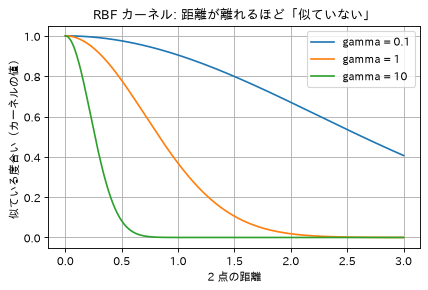

In [ ]:
dist = np.linspace(0, 3, 300)
for g in [0.1, 1, 10]:
    plt.plot(dist, np.exp(-g * dist ** 2), label=f"gamma = {g}")
plt.xlabel("2 点の距離"); plt.ylabel("似ている度合い（カーネルの値）")
plt.legend(); plt.title("RBF カーネル: 距離が離れるほど「似ていない」"); plt.show()

👀 どの `gamma` でも、距離 0（同じ点）で 1、離れるほど 0 に近づきます。`gamma = 10` では距離 0.5 でもう 0.1 を下回りますが、`gamma = 0.1` では距離 3 でもまだ 0.4 ほど残っています。`gamma` は「**どこまで遠くの点を仲間とみなすか**」のつまみです。

### 2 つのハイパーパラメータ

| ハイパーパラメータ | 小さいと | 大きいと |
|---|---|---|
| `gamma`（RBF カーネル） | 遠くの点まで似ているとみなす → なめらか・単純（**アンダーフィット**気味） | 近くの点だけを見る → ぎざぎざ・複雑（**オーバーフィット**気味） |
| `alpha`（正則化） | データにぴったり合わせる → 複雑 | 双対係数を小さく抑える → なめらか・単純 |

### 🧪 やってみよう: `gamma` と `alpha` を変えて、学習される関数を見る

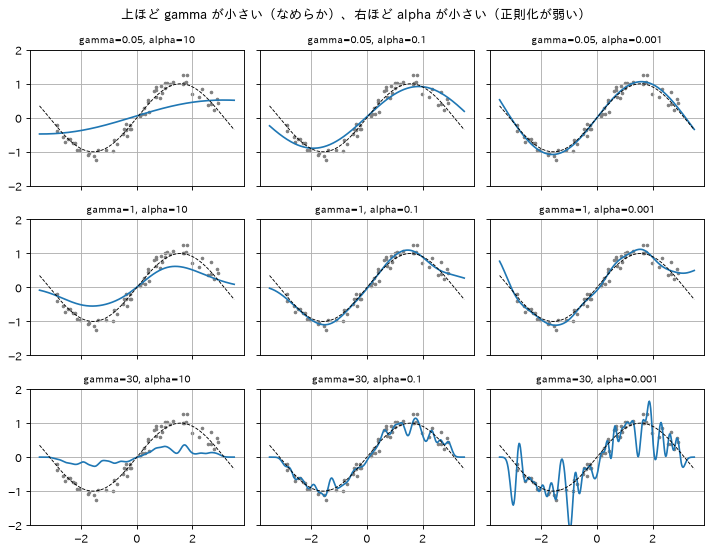

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(9, 7), sharex=True, sharey=True)
for i, g in enumerate([0.05, 1, 30]):
    for j, a_ in enumerate([10, 0.1, 0.001]):
        ax = axes[i, j]
        m = KernelRidge(kernel="rbf", gamma=g, alpha=a_).fit(X, y)
        ax.scatter(X, y, s=5, c="gray")
        ax.plot(grid, m.predict(grid), c="tab:blue")
        ax.plot(grid, np.sin(grid), "k--", lw=0.8)
        ax.set_title(f"gamma={g}, alpha={a_}", fontsize=9); ax.set_ylim(-2, 2)
fig.suptitle("上ほど gamma が小さい（なめらか）、右ほど alpha が小さい（正則化が弱い）")
plt.tight_layout(); plt.show()

### 👀 結果の読み方

- **上段（`gamma` が小さい）**: 遠くの点まで似ているとみなすので、なめらかすぎて、正則化が強い（左）と曲線を捉えきれません。
- **下段（`gamma` が大きい）**: 近くの点しか見ないので、`alpha` が小さい（右）と点を 1 つずつなぞるぎざぎざの関数になり、データのない場所ではすぐ 0 に落ちます。
- 真ん中あたり（`gamma=1`、`alpha=0.1`）が、真の関数（点線）に近くなっています。

### 🧪 やってみよう: グリッドサーチで 2 つを同時に選ぶ

ガイドの図と同じように、`alpha` と `gamma` の組み合わせを交差検証で評価します。

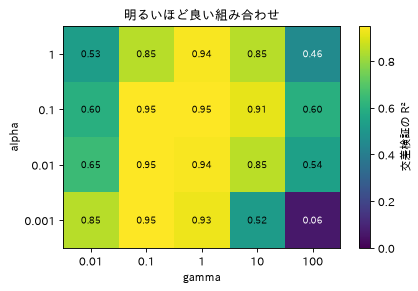

選ばれた組み合わせ: {'alpha': 0.01, 'gamma': np.float64(0.1)} / 交差検証の R²: 0.949


In [8]:
from sklearn.model_selection import KFold
param_grid = {"alpha": [1, 0.1, 0.01, 0.001], "gamma": np.logspace(-2, 2, 5)}
cv = KFold(n_splits=5, shuffle=True, random_state=0)       # X は並べ替えてあるので、シャッフルして分割する（下の ⚠️）
search = GridSearchCV(KernelRidge(kernel="rbf"), param_grid=param_grid, cv=cv).fit(X, y)

scores = search.cv_results_["mean_test_score"].reshape(len(param_grid["alpha"]), len(param_grid["gamma"]))
plt.imshow(scores, cmap="viridis", vmin=0)
plt.xticks(range(5), [f"{g:g}" for g in param_grid["gamma"]]); plt.yticks(range(4), param_grid["alpha"])
plt.xlabel("gamma"); plt.ylabel("alpha"); plt.colorbar(label="交差検証の R²"); plt.grid(False)
for (i, j), v in np.ndenumerate(scores):
    plt.text(j, i, f"{v:.2f}", ha="center", va="center", color="white" if v < 0.5 else "black", fontsize=8)
plt.title("明るいほど良い組み合わせ"); plt.show()
print("選ばれた組み合わせ:", search.best_params_, "/ 交差検証の R²:", round(search.best_score_, 3))

👀 `gamma` が大きすぎる列（右端）は、`alpha` をどう選んでも成績が悪くなります。逆に `gamma` が適度なら、`alpha` の選び方の影響は比較的小さいことが分かります。**2 つのハイパーパラメータは互いに影響し合う**ので、1 つずつではなく組み合わせで探すのが基本です。

> ⚠️ **つまずきポイント（このノートを作るときに実際にはまったもの）**: `GridSearchCV(..., cv=5)` のように数字で指定すると、回帰では**シャッフルせずに**データを 5 つの連続した区間に分けます。このノートの `X` は小さい順に並べてあるので、シャッフルしないと「両端の区間をまるごと隠して当てる」という**外挿**のテストになり、スコアが大きく下がりました（最初はそのせいで R² が 0.48 でした）。データが何かの順に並んでいるときは、`KFold(shuffle=True)` を渡しましょう（3.1 節で詳しく扱います）。

> ⚠️ **つまずきポイント**: `KernelRidge(kernel="rbf")` の `gamma` の既定値は `None` で、このとき $1 / \text{特徴数}$ が使われます。特徴のスケールによって適切な `gamma` は大きく変わるので、既定値のまま使わず、**特徴を標準化したうえでグリッドサーチ**するのが安全です。

---
## 3. 📖 SVR との比較: 損失関数とスパース性

### 📖 ガイドの解説

`KernelRidge` が学習するモデルの**形**は、サポートベクター回帰（SVR）と同じです。ただし、使う**損失関数**が違います。

- KRR: **二乗誤差**の損失
- SVR: **ε-不感損失**（epsilon-insensitive loss）

どちらも L2 正則化と組み合わせます。

SVR と違って、`KernelRidge` の学習は**閉形式**で行え、中規模のデータセットではたいてい SVR より速く学習できます。一方、学習したモデルは**スパースではない**ので、予測のときは SVR より遅くなります。SVR は、$\epsilon > 0$ のとき**スパースなモデル**を学習するからです。

> 📚 **用語**
> - **サポートベクター回帰（SVR）**: サポートベクターマシン（1.4 節）の回帰版。
> - **ε-不感損失（epsilon-insensitive loss）**: 残差の大きさが $\epsilon$ 以下なら罰は 0、それを超えた分だけ直線的に罰する損失。「$\epsilon$ 以内のずれは気にしない」。
> - **サポートベクター**: SVR の学習で、双対係数が 0 でない学習サンプル。予測に使われるのはこのサンプルだけ。
> - **スパースなモデル**: 予測に使う学習サンプルが一部だけのモデル。予測のたびに計算する「似ている度合い」の数が少ないので、予測が速い。

### 🔢 数式を読む: 2 つの損失関数

| 損失 | 式（残差 $r = y - \hat{y}$） | 意味 |
|---|---|---|
| 二乗誤差（KRR） | $r^2$ | どんなに小さなずれも罰する。外れ値は二乗で強く罰する |
| ε-不感損失（SVR） | $\max(0,\ \lvert r \rvert - \epsilon)$ | $\epsilon$ 以内のずれは罰 0。超えた分だけ直線で罰する |

> 📐 **もっと詳しく**: [数式編「2 つの損失関数」](./math/03_kernel_ridge_math.md#loss)（数値の例・導き方つき）

💡 **なぜ SVR はスパースになるのか**: ε-不感損失では、予測との差が $\epsilon$ 以内に収まったサンプルは損失に何も寄与しません。そういうサンプルは答えに影響しないので、双対係数がちょうど 0 になります。KRR の二乗誤差は、どのサンプルも少しずつ罰に寄与するので、**すべての**学習サンプルの双対係数が 0 以外になります。

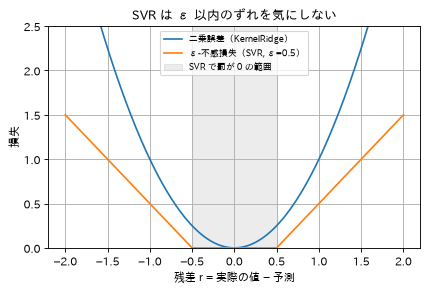

In [9]:
r = np.linspace(-2, 2, 400); eps = 0.5
plt.plot(r, r ** 2, label="二乗誤差（KernelRidge）")
plt.plot(r, np.maximum(0, np.abs(r) - eps), label=f"ε-不感損失（SVR, ε={eps}）")
plt.axvspan(-eps, eps, color="gray", alpha=0.15, label="SVR で罰が 0 の範囲")
plt.xlabel("残差 r = 実際の値 − 予測"); plt.ylabel("損失"); plt.ylim(0, 2.5); plt.legend(fontsize=8)
plt.title("SVR は ε 以内のずれを気にしない"); plt.show()

### 🧪 やってみよう: ε を変えると、サポートベクターの数はどう変わるか

ガイドは「スパースさ（と予測時間）は SVR の $\epsilon$ と $C$ に依存し、$\epsilon = 0$ なら密なモデルになる」と述べています。確かめます。

In [10]:
rows = []
for eps in [0, 0.05, 0.1, 0.2, 0.4]:
    svr = SVR(kernel="rbf", gamma=0.5, C=10, epsilon=eps).fit(X, y)
    rows.append({"epsilon": eps, "サポートベクターの数": len(svr.support_),
                 "学習データに占める割合": len(svr.support_) / len(X), "R²": svr.score(X, y)})
krr_full = KernelRidge(alpha=0.1, kernel="rbf", gamma=0.5).fit(X, y)
rows.append({"epsilon": "（KernelRidge）", "サポートベクターの数": int((krr_full.dual_coef_ != 0).sum()),
             "学習データに占める割合": float((krr_full.dual_coef_ != 0).mean()), "R²": krr_full.score(X, y)})
pd.DataFrame(rows).set_index("epsilon")

,サポートベクターの数,学習データに占める割合,R²
epsilon,,,
0,60,1.0000,0.9671
0.05,47,0.7833,0.9696
0.1,31,0.5167,0.9707
0.2,13,0.2167,0.9695
0.4,4,0.0667,0.9251
（KernelRidge）,60,1.0000,0.9706


### 👀 結果の読み方

- `epsilon=0` では、すべての学習サンプルがサポートベクターになりました（密なモデル）。
- `epsilon` を大きくするほど、サポートベクターが減ってスパースになります。
- 当てはまり（R²）は、`epsilon` が小さいうちはほとんど変わりません。ノイズの大きさ（標準偏差 0.15）程度までの `epsilon` なら、「気にしなくてよいずれ」を無視しているだけだからです。`epsilon=0.4` のように大きくしすぎると、本当の形のずれまで無視して R² が下がります。
- `KernelRidge` は、双対係数がすべて 0 以外です（最下行）。予測のたびに**全学習サンプル**との似ている度合いを計算します。

---
## 4. 📖 ガイドの図 1 の再現: 学習と予測の速さ

### 📖 ガイドの解説

ガイドの図は、人工データで `KernelRidge` と `SVR` を比べています。データは sin 関数を目的変数とし、**5 点に 1 点に強いノイズ**を加えたものです。どちらのモデルも、複雑さ / 正則化と RBF カーネルのバンド幅を、グリッドサーチで最適化しています。

ガイドによると、

- 学習された関数はとてもよく似ている
- ただし `KernelRidge` の学習は、SVR より**約 7 倍速い**（どちらもグリッドサーチ込み）
- 一方、10 万点の予測は、SVR のほうが **3 倍以上速い**。SVR は、学習データ 100 点のうち約 1/3 だけをサポートベクターとして使う、スパースなモデルを学習したからである

### 🧪 やってみよう: ガイドの例と同じ設定で再現する

In [11]:
rng = np.random.RandomState(42)                    # ガイドの例と同じ乱数
X_all = 5 * rng.rand(10000, 1)
y_all = np.sin(X_all).ravel()
y_all[::5] += 3 * (0.5 - rng.rand(X_all.shape[0] // 5))   # 5 点に 1 点、強いノイズ
X_plot = np.linspace(0, 5, 100000)[:, None]
train_size = 100

svr_gs = GridSearchCV(SVR(kernel="rbf", gamma=0.1),
                      param_grid={"C": [1e0, 1e1, 1e2, 1e3], "gamma": np.logspace(-2, 2, 5)})
krr_gs = GridSearchCV(KernelRidge(kernel="rbf", gamma=0.1),
                      param_grid={"alpha": [1e0, 0.1, 1e-2, 1e-3], "gamma": np.logspace(-2, 2, 5)})

timing = {}
for name, model in [("SVR", svr_gs), ("KernelRidge", krr_gs)]:
    fit_t = best_time(lambda: model.fit(X_all[:train_size], y_all[:train_size]))
    pred_t = best_time(lambda: model.predict(X_plot))
    timing[name] = {"学習時間（グリッドサーチ込み, 秒）": fit_t, "10 万点の予測時間（秒）": pred_t,
                    "選ばれたパラメータ": str(model.best_params_)}
n_sv = len(svr_gs.best_estimator_.support_)
print(f"SVR のサポートベクター: {n_sv} / {train_size} 点（{n_sv / train_size:.0%}）")
print(f"学習: KernelRidge は SVR の {timing['SVR']['学習時間（グリッドサーチ込み, 秒）'] / timing['KernelRidge']['学習時間（グリッドサーチ込み, 秒）']:.1f} 倍速い")
print(f"予測: SVR / KernelRidge の時間比 = {timing['SVR']['10 万点の予測時間（秒）'] / timing['KernelRidge']['10 万点の予測時間（秒）']:.2f}（1 より小さければ SVR が速い）")
pd.DataFrame(timing).T

SVR のサポートベクター: 34 / 100 点（34%）
学習: KernelRidge は SVR の 2.5 倍速い
予測: SVR / KernelRidge の時間比 = 1.45（1 より小さければ SVR が速い）


,"学習時間（グリッドサーチ込み, 秒）",10 万点の予測時間（秒）,選ばれたパラメータ
SVR,0.5251,0.0853,"{'C': 1.0, 'gamma': np.float64(0.1)}"
KernelRidge,0.2113,0.059,"{'alpha': 0.1, 'gamma': np.float64(0.1)}"


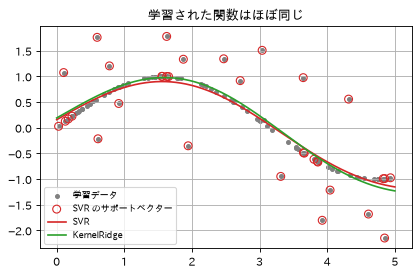

In [12]:
sv = svr_gs.best_estimator_.support_
plt.scatter(X_all[:train_size], y_all[:train_size], s=12, c="gray", label="学習データ", zorder=1)
plt.scatter(X_all[sv], y_all[sv], s=50, facecolors="none", edgecolors="tab:red", label="SVR のサポートベクター", zorder=2)
plt.plot(X_plot, svr_gs.predict(X_plot), c="tab:red", label="SVR")
plt.plot(X_plot, krr_gs.predict(X_plot), c="tab:green", label="KernelRidge")
plt.legend(fontsize=8); plt.title("学習された関数はほぼ同じ"); plt.show()

### 👀 結果の読み方

- **学習された関数**: SVR と KernelRidge の曲線はほぼ重なっています。ガイドのとおりです。
- **サポートベクター**: SVR は、学習データの約 3 分の 1 だけを使っています（赤い丸）。これもガイドのとおりです。強いノイズの点（大きく外れた点）の多くがサポートベクターになっていることにも注目してください。
- **学習時間**: KernelRidge のほうが速いという傾向はガイドと同じですが、倍率はガイドの「約 7 倍」より小さくなりました（上の出力を参照）。
- **予測時間**: ガイドでは「SVR が 3 倍以上速い」とされていますが、**この環境では KernelRidge のほうが速い、または同程度**でした（上の出力を参照）。

> ⚠️ **ガイドの主張が再現しなかった理由（推測）**: 速さは、アルゴリズムの計算量だけでなく**実装**にも左右されます。KernelRidge の予測は「行列 × ベクトル」の 1 回の計算で、最近の数値計算ライブラリ（BLAS）で非常に速く処理されます。一方 SVR は libsvm という別のライブラリの実装を使います。学習データが 100 点と少ないので、「計算する似ている度合いの数が 1/3 で済む」という SVR の利点より、実装の違いのほうが大きく効いたと考えられます。**ガイドに載っている速度の数字は、実行環境やバージョンによって変わりうる**ことを覚えておきましょう。

---
## 5. 📖 ガイドの図 2 の再現: データ量による速さの変化

### 📖 ガイドの解説

次の図は、学習データの大きさを変えて、`KernelRidge` と `SVR` の学習時間と予測時間を比べたものです。

- **学習**: 中規模の学習データ（1000 サンプル未満）では `KernelRidge` のほうが速いが、それより大きい学習データでは SVR のほうがスケールする（データが増えても時間の増え方が緩やか）。
- **予測**: スパースな解を学習するので、どの大きさの学習データでも SVR のほうが速い。
- ただし、スパースさの度合い（したがって予測時間）は、SVR の $\epsilon$ と $C$ に依存する。$\epsilon = 0$ なら密なモデルになる。

> 📚 **用語**: **スケールする** — データが大きくなっても、計算時間やメモリが急に増えないこと。

### 💡 補足: なぜ KernelRidge は大きなデータに弱いのか

- **学習**: $n \times n$ のカーネル行列 $K + \alpha I$ の連立方程式を解くので、計算量はおよそ $O(n^3)$。データが 10 倍になると、学習時間は約 1000 倍になります。
- **メモリ**: カーネル行列は $n^2$ 個の数を持ちます。1 万件なら 1 億個（約 800 MB）、10 万件なら 100 億個（約 80 GB）で、普通のコンピュータのメモリに乗りません。
- **予測**: 新しい点 1 つにつき、全 $n$ 個の学習サンプルとの似ている度合いを計算するので、$O(n)$。

SVR も一般に $n$ の 2 乗〜3 乗程度で重くなりますが、サポートベクターだけを扱う工夫があるので、KRR より緩やかに増えます。

### 🧪 やってみよう: 学習データの大きさを変えて時間を測る

ガイドの例と同じデータで、学習データを 100 件から 4000 件まで増やします（ハイパーパラメータは固定。予測は 1 万点。3 回の最小値）。

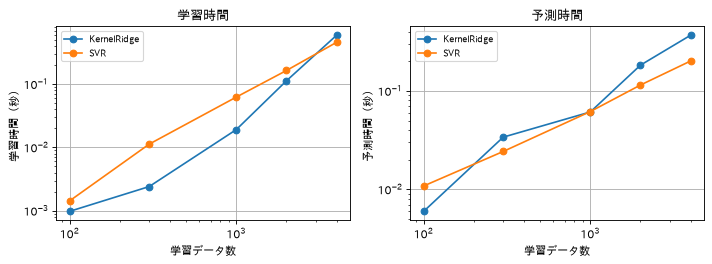

学習時間                予測時間           サポートベクター数       
モデル    KernelRidge     SVR KernelRidge     SVR KernelRidge    SVR
学習データ数                                                           
100         0.0010  0.0014      0.0060  0.0108       100.0   45.0
300         0.0024  0.0113      0.0339  0.0243       300.0  106.0
1000        0.0191  0.0624      0.0611  0.0617      1000.0  267.0
2000        0.1129  0.1642      0.1827  0.1148      2000.0  496.0
4000        0.5922  0.4577      0.3680  0.2014      4000.0  874.0

In [13]:
sizes = [100, 300, 1000, 2000, 4000]
records = []
for n in sizes:
    for name, make in [("SVR", lambda: SVR(kernel="rbf", C=1e1, gamma=10)),
                       ("KernelRidge", lambda: KernelRidge(kernel="rbf", alpha=0.1, gamma=10))]:
        model = make()
        fit_t = best_time(lambda: model.fit(X_all[:n], y_all[:n]))
        pred_t = best_time(lambda: model.predict(X_plot[:10000]))
        records.append({"学習データ数": n, "モデル": name, "学習時間": fit_t, "予測時間": pred_t,
                        "サポートベクター数": len(model.support_) if name == "SVR" else n})
df_t = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for ax, col in zip(axes, ["学習時間", "予測時間"]):
    for name, g in df_t.groupby("モデル"):
        ax.loglog(g["学習データ数"], g[col], marker="o", label=name)
    ax.set_xlabel("学習データ数"); ax.set_ylabel(f"{col}（秒）"); ax.set_title(col); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
df_t.pivot(index="学習データ数", columns="モデル", values=["学習時間", "予測時間", "サポートベクター数"])

### 👀 結果の読み方（両対数グラフ: 傾きが急なほど、データ量の増加に弱い）

- **学習時間**: 小さいデータでは KernelRidge と SVR は同程度か KernelRidge が速く、データが大きくなると KernelRidge の線が**急な傾き**で上がり、SVR を追い越します。ガイドの「大きな学習データでは SVR のほうがスケールする」は、この環境でも再現しました。追い越す位置（何件から SVR が速くなるか）は、実行環境によって変わります。
- **予測時間**: 学習データがある程度大きくなると、SVR のほうが速くなりました。サポートベクター数が学習データ数より少ない（表の右端）ので、計算する似ている度合いが少なくて済むからです。ただし、学習データがごく小さい（100 件）ところでは KernelRidge のほうが速く、ガイドの「どの大きさでも SVR が速い」は、この環境では再現しませんでした（図 1 の再現と同じ理由と考えられます）。

> 🧩 **設計の視点**: 「学習が速いか」「予測が速いか」は、使い方によって重要度が変わります。1 回学習して何百万回も予測する Web サービスなら予測の速さが、データが毎日変わって頻繁に学習し直すなら学習の速さが大事です。

---
## 6. 💡 ガウス過程回帰との関係

（ガイドに書かれていない補足です。1.7 節「ガウス過程」への橋渡しです。）

カーネルリッジ回帰の予測は、同じカーネルを使った**ガウス過程回帰**（`GaussianProcessRegressor`）の予測の**平均**と一致します。KRR の `alpha` が、ガウス過程回帰の `alpha`（観測ノイズの分散）に当たります。ガウス過程回帰は、それに加えて予測の**不確かさ**（標準偏差）も出せます。1.1 の 2/4 の「Ridge と Bayesian Ridge」の関係の、カーネル版だと考えるとよいでしょう。

> 📚 **用語**: **ガウス過程（Gaussian process）** — 関数そのものに確率分布を考え、「どんな関数がありそうか」をカーネルで表すベイズ的な方法（1.7 節）。

GaussianProcessRegressor の予測の平均と KernelRidge の予測が一致: True


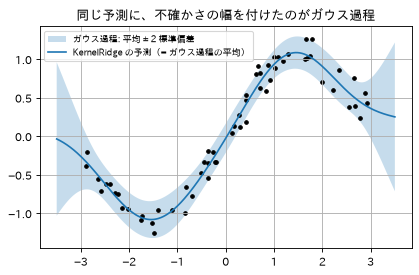

In [14]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

gamma, alpha = 0.5, 0.1
krr = KernelRidge(kernel="rbf", gamma=gamma, alpha=alpha).fit(X, y)
# RBF の長さスケール ℓ と gamma の関係: gamma = 1 / (2 ℓ²)
gpr = GaussianProcessRegressor(kernel=RBF(length_scale=1 / np.sqrt(2 * gamma)), alpha=alpha, optimizer=None).fit(X, y)

mean, std = gpr.predict(grid, return_std=True)
print("GaussianProcessRegressor の予測の平均と KernelRidge の予測が一致:", np.allclose(mean, krr.predict(grid)))
plt.fill_between(grid[:, 0], mean - 2 * std, mean + 2 * std, alpha=0.25, label="ガウス過程: 平均 ± 2 標準偏差")
plt.plot(grid, krr.predict(grid), label="KernelRidge の予測（= ガウス過程の平均）")
plt.scatter(X, y, s=10, c="black")
plt.legend(fontsize=8); plt.title("同じ予測に、不確かさの幅を付けたのがガウス過程"); plt.show()

### 🏢 実務での選ばれ方: カーネルリッジ回帰（`KernelRidge`）

- ✅ **特に選ばれる場面**: 数百〜数千件のデータで、なめらかな曲線の関係を予測したいとき（化学・材料の物性予測、センサーの校正、地点の間の補間）。答えが閉形式で、調整するのが `alpha` と `gamma` くらいなので扱いやすい。
- ❌ **選ばれない場面**: データが 1 万件を超える（n × n の表がメモリに乗らない）。予測を速くしたい（毎回、全学習データとの似ている度合いを計算する）。カテゴリと数値が混ざった表形式のデータ → 勾配ブースティング。
- 🔗 **実務でよくある組み合わせ・代わりの手法**: 大きなデータでは、`Nystroem` や `RBFSampler`（カーネル近似、6.7 節）で特徴を作ってから `Ridge` や `SGDRegressor` で学習するのが定番です。予測の不確かさも欲しいならガウス過程（1.7 節）、予測を軽くしたいなら SVR（1.4 節）。表形式のデータで精度を重視するなら、勾配ブースティングと比べます。

---
## 7. まとめ

### 比較表

| | Ridge（1.1） | KernelRidge | SVR（1.4） | GaussianProcessRegressor（1.7） |
|---|---|---|---|---|
| 学習する関数 | 線形 | カーネル次第で非線形 | カーネル次第で非線形 | カーネル次第で非線形 |
| 損失 | 二乗誤差 | 二乗誤差 | ε-不感損失 | 二乗誤差（正規分布のノイズ） |
| 学習方法 | 閉形式 | 閉形式（$n \times n$ の連立方程式） | 反復（二次計画問題） | 閉形式 + カーネルのパラメータの最適化 |
| 予測に使うサンプル | —（係数だけ） | 全学習サンプル（密） | サポートベクターだけ（スパース） | 全学習サンプル |
| 切片 | あり | **なし** | あり | なし（`normalize_y` で平均を扱える） |
| 予測の不確かさ | — | — | — | ✅ |
| 向いているデータ量 | 大規模まで | 中規模（〜数千件） | 中規模〜やや大きめ | 小〜中規模 |

### 🔄 カーネルリッジ回帰を 3 つの角度から

| 角度 | 内容 |
|---|---|
| たとえ | 「似ている過去の物件の家賃を、似ている度合いで重み付けして足す」不動産屋 |
| 図 | `gamma` と `alpha` の 3 × 3 の図: `gamma` が大きいとぎざぎざ、`alpha` が大きいとなめらか |
| 数 | 学習データ 60 件 → 60 × 60 の似ている度合いの表で、連立方程式を 1 回解くだけ |

### 覚えておきたい 3 つのこと

1. **カーネルリッジ回帰 = 特徴空間での Ridge 回帰**。カーネルトリックで、特徴を作らずに「似ている度合い」だけで計算する。予測は「学習サンプルとの似ている度合い × 発言力」の和。
2. **RBF カーネルでは `gamma`（どこまでを似ているとみなすか）と `alpha`（正則化）を組み合わせで選ぶ**。グリッドサーチが基本。
3. **KRR と SVR は同じ形のモデルで、損失関数が違う**。KRR は閉形式で中規模の学習が速く、SVR はスパースで大きなデータや予測に強い。ただし実際の速さは実装と環境に左右される。

### 🧩 ドメインモデルの視点

- `KernelRidge` の `kernel` 引数には、`"rbf"` などの**文字列**も、Python の**関数**も渡せます。「似ている度合いの計算方法」を**差し替え可能な部品**として外に出した設計で、TypeScript なら `kernel: "rbf" | "poly" | ((a: Vector, b: Vector) => number)` のような型になります（ストラテジーパターン）。
- `KernelRidge` は学習データ全体（の変換に必要な情報）を内部に保持し、予測のたびに使います。1.1 の線形モデルが「学習後は係数だけを持つ」のと対照的で、**モデルの大きさが学習データの量に比例**します。保存（11 章）やメモリの見積もりのときに注意が必要です。
- `KernelRidge` には切片がなく、`Ridge` にはあります。同じ「Ridge」という名前でも、**インターフェースの細部（引数や学習する属性）は同じではありません**。

### ✅ 確認クイズ

**Q1.** カーネルトリックの利点を、一言で説明してください。

<details><summary>答え</summary>

高次元（無限次元でも）の特徴空間の座標を実際に計算せず、2 点の「似ている度合い」（内積）だけで、その空間での線形モデルを学習・予測できること。
</details>

**Q2.** 学習データが 100 件のとき、`KernelRidge` の学習で解く連立方程式の大きさはいくつですか。

<details><summary>答え</summary>

100 × 100（カーネル行列 $K + \alpha I$ の大きさ = 学習データ数 × 学習データ数）。特徴の数には関係しません。
</details>

**Q3.** RBF カーネルの `gamma` を大きくしすぎると、学習される関数はどうなりますか。

<details><summary>答え</summary>

近くの点しか「似ている」とみなさないので、データを 1 点ずつなぞるぎざぎざの関数になり（過学習）、データのない場所ではすぐ 0 に戻る。
</details>

**Q4.** SVR のモデルがスパースになるのはなぜですか。`epsilon=0` だとどうなりますか。

<details><summary>答え</summary>

ε-不感損失では、予測との差が ε 以内のサンプルは損失に寄与せず、双対係数が 0 になるからです。`epsilon=0` では全サンプルが寄与するので、密なモデルになります。
</details>

**Q5.** 目的変数の平均が 1000 くらいのデータに `KernelRidge(kernel="rbf")` を使うとき、注意することは何ですか。

<details><summary>答え</summary>

`KernelRidge` には切片がないので、データから離れた場所で予測が 0 に落ちてしまいます。目的変数から平均を引いて学習し、予測に足し戻す（`TransformedTargetRegressor` などを使う）ようにします。
</details>

---
**前の節**: [1.2 線形判別分析と二次判別分析](./02_lda_qda.ipynb) ・ **次の節**: [1.4 サポートベクターマシン（1/2）](./04_svm_1_classification_regression.ipynb)